In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from agent.prompt.sys import SYSTEM_PROMPT
from firecrawl import Firecrawl
from langchain_tavily import TavilySearch , TavilyExtract 
from db.vector import retriever

c:\Users\BHUMIT SINGH\Documents\AGENTIC AI\Campus Bot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
llm = ChatGroq(model="openai/gpt-oss-120b")


In [4]:
# from langchain_openrouter import ChatOpenRouter

# llm = ChatOpenRouter(
#     model="openai/gpt-oss-120b:free",
#     temperature=0.8,
# )


In [4]:
app = Firecrawl()
tavily = TavilySearch()
tavily_extract=TavilyExtract(extract_depth="basic",format="markdown")


In [6]:
class GlobalState(TypedDict):
    query: str
    messages: Annotated[list[BaseMessage], add_messages]


Academic schedule
Examination updates
Events
Administrative procedures
Institutional services


In [7]:
@tool
def get_attendence(computer_code: str, password: str):
    """Tools to get the attence of a student student"""
    result = app.scrape(
        "https://cms2.ipsacademy.net/Login/sign_in", formats=["markdown"]
    )
    scrape_id = result.metadata.scrape_id
    app.interact(
        scrape_id,
        prompt=f"login using computer code - {computer_code} , pass- {password}",
    )
    response = app.interact(scrape_id, prompt="return the attendence")
    return response.output

In [8]:
@tool
def get_syllabus(
    course: Literal[
        "CSE-AIML",
        "CSE",
        "CS-IT",
        "CSE-DS",
    ],
):
    """Get syllabus link from IPS Academy. Searches official site only."""
    if course == "CSE":
        result = tavily_extract.invoke(
            {
                "urls": [
                    "https://ies.ipsacademy.org/departments/computer-science-engg/scheme-syllabus/"
                ]
            }
        )
        return result
    if(course=="CSE-AIML"):
        result = tavily_extract.invoke(
            {
                "urls": [
                    "https://ies.ipsacademy.org/departments/computer-science-engineering-artificial-intelligence-machine-learning/scheme-syllabus/"
                ]
            }
        )
        return result
    if(course=="CSE-DS"):
        result = tavily_extract.invoke(
            {
                "urls": [
                    "https://ies.ipsacademy.org/departments/scheme-syllabus-2/"
                ]
            }
        )
        return result
    if(course=="CS-IT"):
        result = tavily_extract.invoke(
            {
                "urls": [
                    "https://ies.ipsacademy.org/scheme-syllabus/"
                ]
            }
        )
        return result

In [9]:
@tool
def academic_calander():
    """Get the examination schedules and the academic calander"""
    print("Calender")
    result = tavily_extract.invoke(
        {"urls": ["https://ies.ipsacademy.org/academics/academic-calendar"]}
    )
    return result['results'][0]['raw_content']

In [10]:
@tool
def scrape_url(url: str):
    """Tool to get the content of a pdf or scrape information from a webpage"""
    print("Parsing Pdf - ",url)
    doc = app.scrape(url,formats=['markdown'])
    return doc.markdown

In [11]:
@tool
def academic_programs(course: Literal["BE/BTech", "ME/MTech"]):
    """Get the Academic programs and courses provided by institute"""
    print("getting academic programs")
    if course == "ME/MTech":
        result = tavily_extract.invoke(
            {"urls": ["https://ies.ipsacademy.org/academics/academic-programs/m-e"]}
        )
        return result['results'][0]['raw_content']
    else:
        result = tavily_extract.invoke(
            {"urls": ["https://ies.ipsacademy.org/academics/academic-programs/b-e"]}
        )
        return result['results'][0]['raw_content']


In [12]:
@tool
def upcoming_events():
    """Use this tool to get the upcoming institute events"""
    result = tavily_extract.invoke(
        {"urls": ["https://ies.ipsacademy.org/category/upcoming/"]}
    )
    return result["results"][0] 

In [13]:
@tool
def admission_procedure():
    """Tool to get the admission procedure at institute"""
    result = tavily_extract.invoke(
        {"urls": ["https://ies.ipsacademy.org/adminssion/admission-procedure/"]}
    )
    return result["results"][0]


In [14]:
@tool
def institute_brochure(query:str):
    """Brochure contains information related to and about Institute"""
    docs=retriever(query=query,namespace="campus")
    return docs

In [15]:
@tool
def code_of_conduct(query:str,whos:Literal["coc-student","coc-employee"]):
    """Get the code of conduct of student and employee"""
    docs=retriever(query=query,namespace=whos)
    return docs


In [16]:
@tool 
def rules_regulations(query:str):
    """Get the rules and regulations of the institute"""
    docs=retriever(query=query,namespace="rules-regulations")
    return docs

In [17]:
@tool
def placements():
    """Tool to get the information regarding placements"""
    result = tavily_extract.invoke(
        {"urls": ["https://ies.ipsacademy.org/training/"]}
    )
    return result["results"][0]

In [18]:
from langgraph.prebuilt import ToolNode

tools = [
    get_attendence,
    get_syllabus, 
    scrape_url,
    academic_calander,
    upcoming_events,
    academic_programs,
    admission_procedure,
    institute_brochure,
    code_of_conduct,
    rules_regulations,
    placements
]
toolnode = ToolNode(tools) 

In [29]:
from datetime import date

today = date.today()
print(today)  # 2026-07-01 14:30:45.123456

2026-07-02


In [19]:
from langchain_core.messages import SystemMessage


def chat(state: GlobalState):
    print('CHat')
    res = llm.bind_tools(tools).invoke(
        [SystemMessage(content=SYSTEM_PROMPT), *state["messages"]]
    )
    # print(res)
    return {"messages": [res]}

In [20]:
checkpoint = MemorySaver()

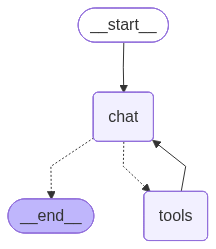

In [26]:
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage

graph = StateGraph(GlobalState)
graph.add_node("chat", chat)
graph.add_edge(START, "chat")
graph.add_node("tools", toolnode)
graph.add_conditional_edges("chat", tools_condition)
graph.add_edge("tools", "chat")
graph.add_edge("chat", END)
wf = graph.compile(checkpointer=checkpoint)
graph.compile()


In [22]:
while True:
    a = input("- ")
    if a == "`":
        break
    print("User - ",a)
    for i,j in wf.stream({"messages": [HumanMessage(content=a)]} ,config={'configurable':{'thread_id':0.11}},stream_mode="messages"):
        print(i.content, end='',flush=True)

    print("\n-------------------")

In [23]:
# result = tavily_extract.invoke(
#     {"urls": ["https://ies.ipsacademy.org/academics/academic-programs/b-e"]}
# )
# result

In [55]:
result = app.scrape("https://cms2.ipsacademy.net/Login/sign_in", formats=["markdown"])
scrape_id = result.metadata.scrape_id
res = app.interact(
    scrape_id,
    prompt=f'SignIn using computer code: {"70010"} , password: {"18-03-2007"} , return in JSON: {{"success":boolean,"details":"error message"}}',
)
response = app.interact(
    scrape_id,
    prompt="From top right corner , select my profile , return all the primary information + Branch , semester , enroll no. , return a valid json {'success':boolean,'message':str}",
)
app.stop_interaction(scrape_id)

BrowserDeleteResponse(success=True, session_duration_ms=28902, credits_billed=7, error=None)

In [56]:
response.output

'```json\n{\n  "success": true,\n  "message": {\n    "Name": "BHUMIT SINGH",\n    "Branch": "AIML",\n    "Semester": "4",\n    "Enrollment No.": "0808CL241048",\n    "Course": "B.Tech.",\n    "Year": "2",\n    "Academic Session": "2025-2026(Jan-June)",\n    "Category": "SC",\n    "Computer Code": "70010",\n    "Gender": "M",\n    "Blood Group": "A+",\n    "Date of Birth": "18-03-2007",\n    "Date Of Admission": "2024-12-20",\n    "Mobile No.": "9826972085",\n    "Email": "Sbhumit828@gmail.com"\n  }\n}\n```'

In [54]:
import json
from langchain_core.output_parsers import JsonOutputParser

JsonOutputParser().parse(res.output)


{'success': False, 'details': 'Computer Code or Password incorrect'}

In [ ]:
from langgraph.store.memory import AsyncInMemoryStore

data = {"name": "abc", "calss": "2nd", "roll": 12}
store = InMemoryStore()
namespace = ("student",str("70010"))
a=store.put(namespace, "profile" , data)


In [99]:
s=store.get(('student',"70010"),'profile')